*This dataset provides comprehensive information on the air pollution index of over 2164 cities across Asia for the year 2023. It covers countries including Armenia, Azerbaijan, Bahrain, Bangladesh, Cambodia, China, Georgia, Hong Kong SAR, India, Indonesia, Iraq, Japan, Kazakhstan, Kuwait, Kyrgyzstan, Laos, Macao SAR, Malaysia, Maldives, Mongolia, Myanmar, Nepal, Pakistan, Palestinian Territory, Philippines, Qatar, Saudi Arabia, Singapore, South Korea, Sri Lanka, Taiwan, Tajikistan, Thailand, Turkey, United Arab Emirates, Uzbekistan, and Vietnam.
The dataset includes the ranking of cities based on their annual average PM2.5 concentration (μg/m³).
Each entry contains details such as the rank of the city, city name, average pollution index for the year 2023, as well as monthly pollution levels from January to December. Additionally, it provides the corresponding country for each city.*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install --quiet catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.5 MB/s eta 0:00:00


In [ ]:
   !pip install --quiet xgboost

In [ ]:
import pandas as pd
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import numpy as np
import seaborn as sns
import umap.umap_ as umap
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
import scipy.stats as scs
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.ensemble import RandomForestClassifier,VotingClassifier, StackingClassifier
from sklearn.feature_selection import RFE
import sys
# sklearn & stats
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_auc_score)
from sklearn.metrics import roc_auc_score, roc_curve

# correlation / mutual information / VIF
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
# models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


In [ ]:
file_path = '/content/drive/MyDrive/AirQuality Dataset.csv'
df = pd.read_csv(file_path)

In [ ]:
print(f"Shape: {df.shape}")
display(df.head())

Shape: (2164, 16)


,Rank,City,Country,2023,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,1,Begusarai,India,118.9,31.2,235.3,156.8,113,109.3,99,63.8,61.8,71.5,61.8,210.5,285
1,2,Guwahati,India,105.4,220.2,168.1,129.2,112.2,69.5,51.3,46.6,60.2,76.7,76.4,126.9,128
2,3,Delhi,India,102.1,171.8,114.3,77.4,71,67.4,42.9,35.3,34.8,39.7,106.3,255.1,210
3,4,Mullanpur,India,100.4,106.3,123.7,78.1,56.6,53.4,53.9,63.2,59.7,59.6,110.4,253,201.4
4,5,Lahore,Pakistan,99.5,143.2,117.3,73.8,52.9,52.4,46.4,39.8,42.2,53.8,125.9,251,197.5


from matplotlib import pyplot as plt
_df_0['Rank'].plot(kind='hist', bins=20, title='Rank')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['2023'].plot(kind='hist', bins=20, title='2023')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_2.groupby('City').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['Mar'].value_counts()
    for x_label, grp in _df_16.groupby('Feb')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Feb')
_ = plt.ylabel('Mar')

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_17['City'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_17, x='Rank', y='City', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_18['Country'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_18, x='Rank', y='Country', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_19['Jan'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_19, x='Rank', y='Jan', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_20['Feb'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_20, x='Rank', y='Feb', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
# --- CLEANING NON-NUMERIC ENTRIES IN NUMERIC COLUMNS ---
numeric_cols = df.columns[3:]  # columns from "2023" onward

# Convert non-numeric entries (like blanks or strings) to NaN
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check how many NaNs are now present
print("\n Cleaned non-numeric entries. Missing values per column:")
print(df[numeric_cols].isna().sum())


✅ Cleaned non-numeric entries. Missing values per column:
2023     0
Jan     87
Feb     66
Mar     33
Apr      9
May     58
Jun      6
Jul      4
Aug     11
Sep     11
Oct     31
Nov     91
Dec     51
dtype: int64


In [ ]:
# --- Mean Imputation ---
mean_imputer = SimpleImputer(strategy='mean')
df_mean = df.copy()
df_mean.iloc[:, 3:] = mean_imputer.fit_transform(df_mean.iloc[:, 3:])

In [ ]:
# --- Median Imputation ---
median_imputer = SimpleImputer(strategy='median')
df_median = df.copy()
df_median.iloc[:, 3:] = median_imputer.fit_transform(df_median.iloc[:, 3:])

In [ ]:
# --- Mode Imputation ---
mode_imputer = SimpleImputer(strategy='most_frequent')
df_mode = df.copy()
df_mode.iloc[:, 3:] = mode_imputer.fit_transform(df_mode.iloc[:, 3:])

In [ ]:
# --- KNN Imputation ---
knn_imputer = KNNImputer(n_neighbors=5)
df_knn = df.copy()
df_knn.iloc[:, 3:] = knn_imputer.fit_transform(df_knn.iloc[:, 3:])

In [ ]:
# --- Iterative Imputation ---
iter_imputer = IterativeImputer(max_iter=10, random_state=42)
df_iter = df.copy()
df_iter.iloc[:, 3:] = iter_imputer.fit_transform(df_iter.iloc[:, 3:])

In [ ]:
# --- Linear Interpolation ---
df_interp = df.copy()
df_interp.iloc[:, 3:] = df_interp.iloc[:, 3:].interpolate(method='linear', axis=0)

print("✅ Missing values handled using multiple techniques")

✅ Missing values handled using multiple techniques


In [ ]:
#OUTLIER DETECTION AND HANDLING
# ==========================================

# --- Z-Score Method ---
z_scores = np.abs(stats.zscore(df[numeric_cols]))
df_zscore = df[(z_scores < 3).all(axis=1)]
print(f"Removed {(len(df)-len(df_zscore))} outliers using Z-Score")


Removed 2164 outliers using Z-Score


In [ ]:
# --- IQR Method ---
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
df_iqr = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]
print(f"Removed {(len(df)-len(df_iqr))} outliers using IQR")

Removed 359 outliers using IQR


In [ ]:
# --- Isolation Forest ---
iso = IsolationForest(contamination=0.05, random_state=42)
yhat = iso.fit_predict(df[numeric_cols])
mask = yhat != -1
df_iso = df[mask]
print(f"Removed {(len(df)-len(df_iso))} outliers using Isolation Forest")

Removed 109 outliers using Isolation Forest


In [ ]:
# --- Local Outlier Factor ---
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
# --- Local Outlier Factor (using mean-imputed data to avoid NaN issues) ---
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
yhat_lof = lof.fit_predict(df_mean[numeric_cols])
mask_lof = yhat_lof != -1
df_lof = df_mean[mask_lof]
print(f"Removed {(len(df_mean)-len(df_lof))} outliers using LOF (on mean-imputed data)")
print(f"Removed {(len(df)-len(df_lof))} outliers using LOF")

Removed 109 outliers using LOF (on mean-imputed data)
Removed 109 outliers using LOF


<Figure size 1500x800 with 0 Axes>

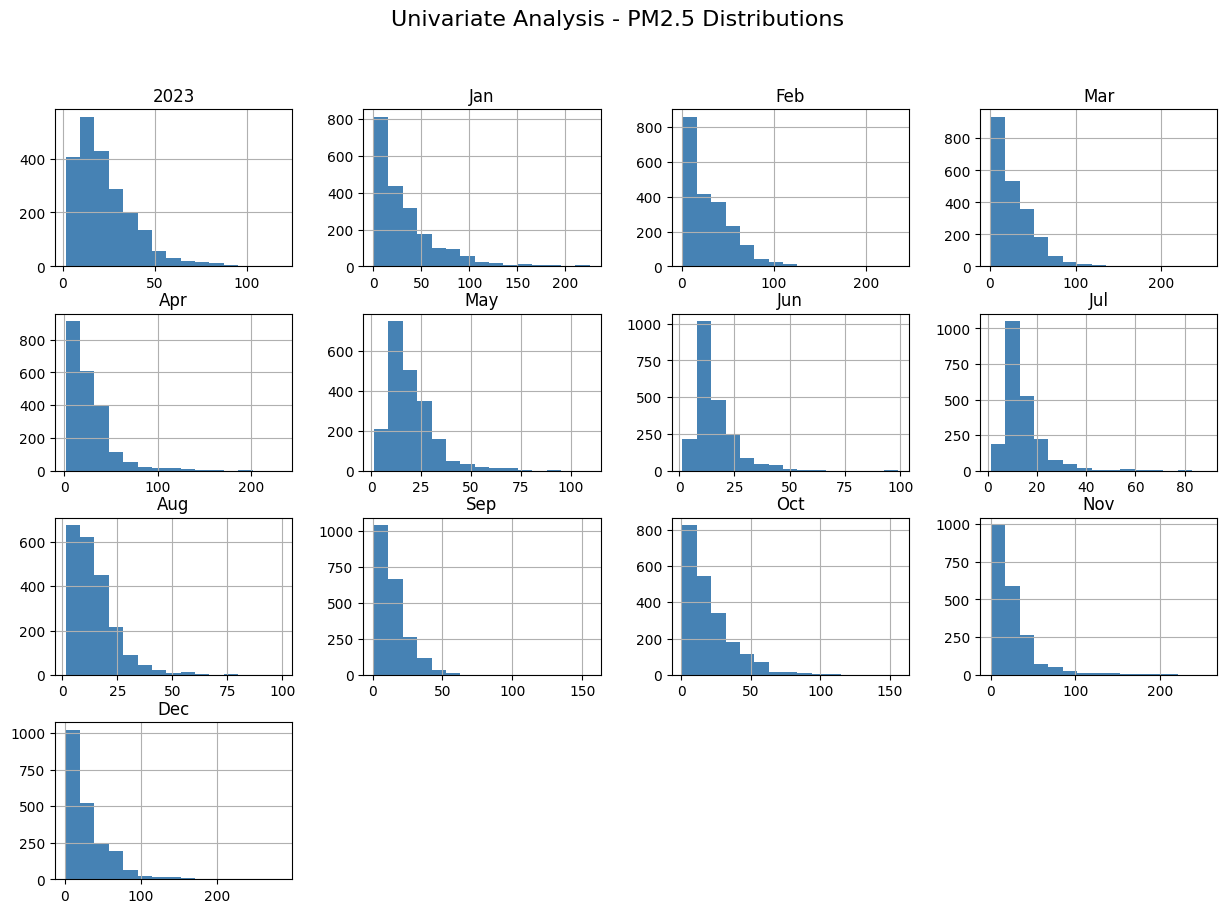

In [ ]:
#  UNIVARIATE ANALYSIS
# ==========================================

plt.figure(figsize=(15,8))
df[numeric_cols].hist(bins=15, figsize=(15,10), color='steelblue')
plt.suptitle("Univariate Analysis - PM2.5 Distributions", fontsize=16)
plt.show()

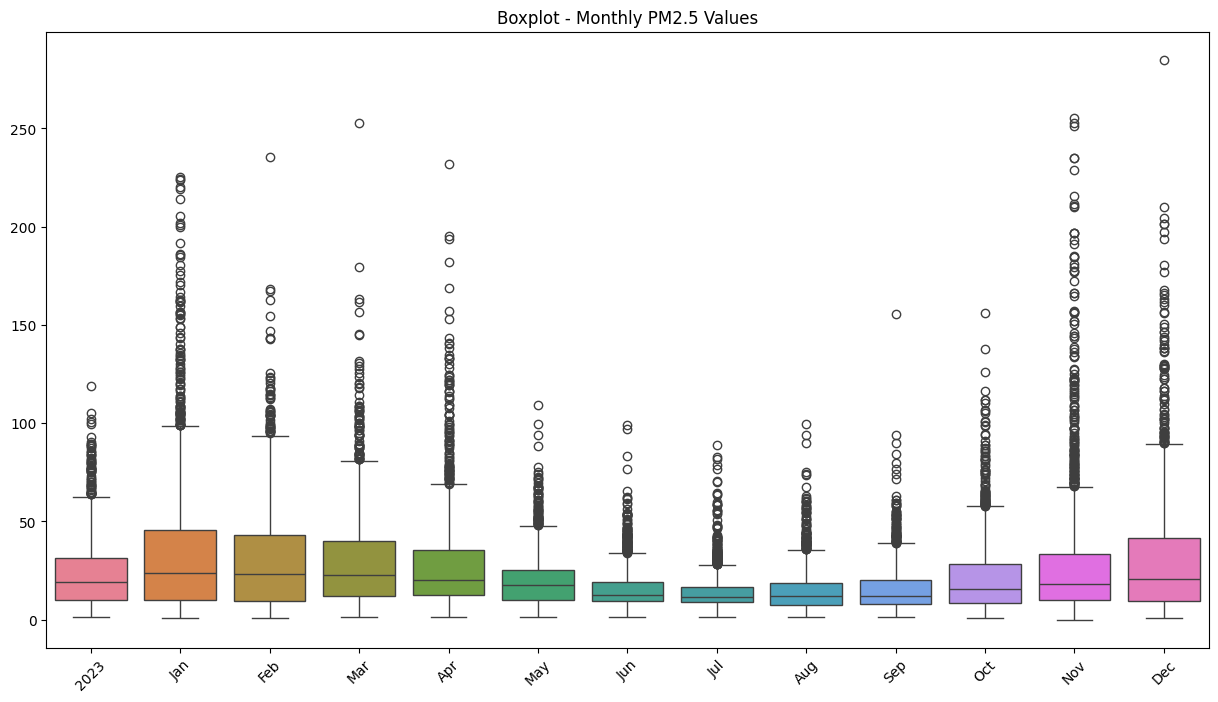

In [ ]:
# Boxplots for visualizing outliers
plt.figure(figsize=(15,8))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot - Monthly PM2.5 Values")
plt.xticks(rotation=45)
plt.show()

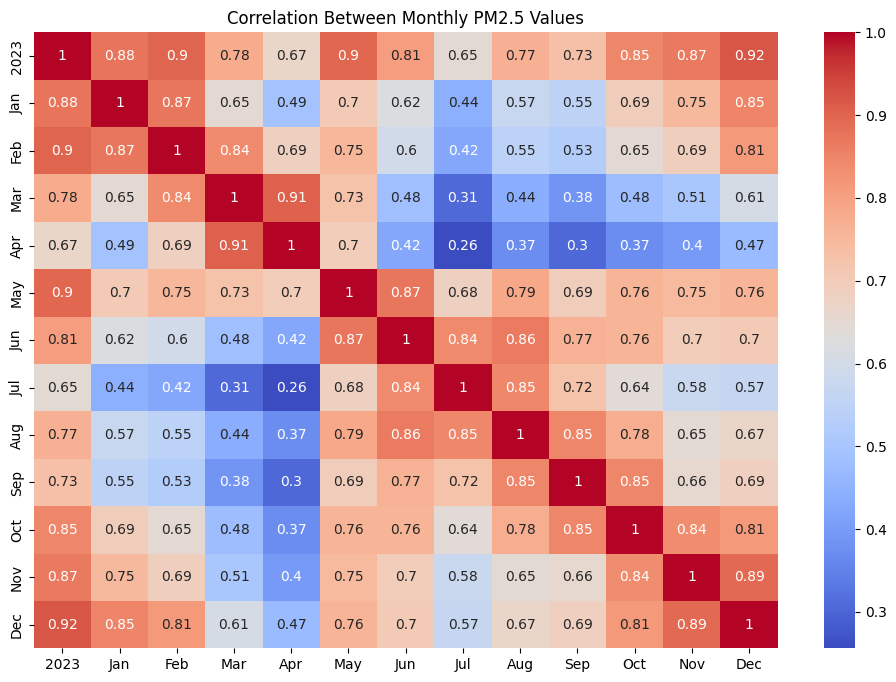

In [ ]:
# BIVARIATE ANALYSIS
# ==========================================

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Monthly PM2.5 Values")
plt.show()

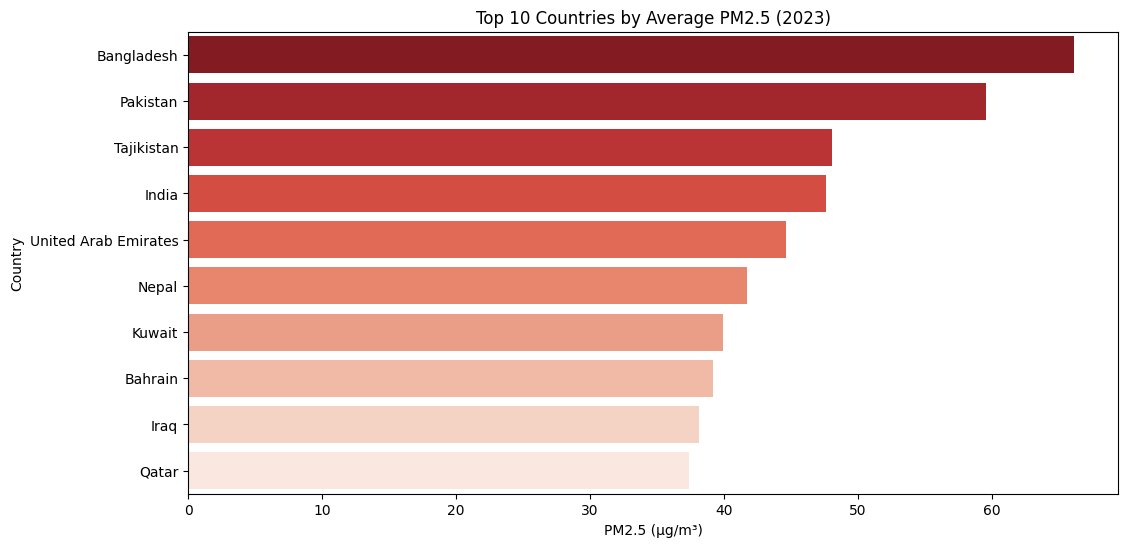

In [ ]:
# Country vs Average Pollution
plt.figure(figsize=(12,6))
top_countries = df.groupby('Country')['2023'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')
plt.title("Top 10 Countries by Average PM2.5 (2023)")
plt.xlabel("PM2.5 (μg/m³)")
plt.show()

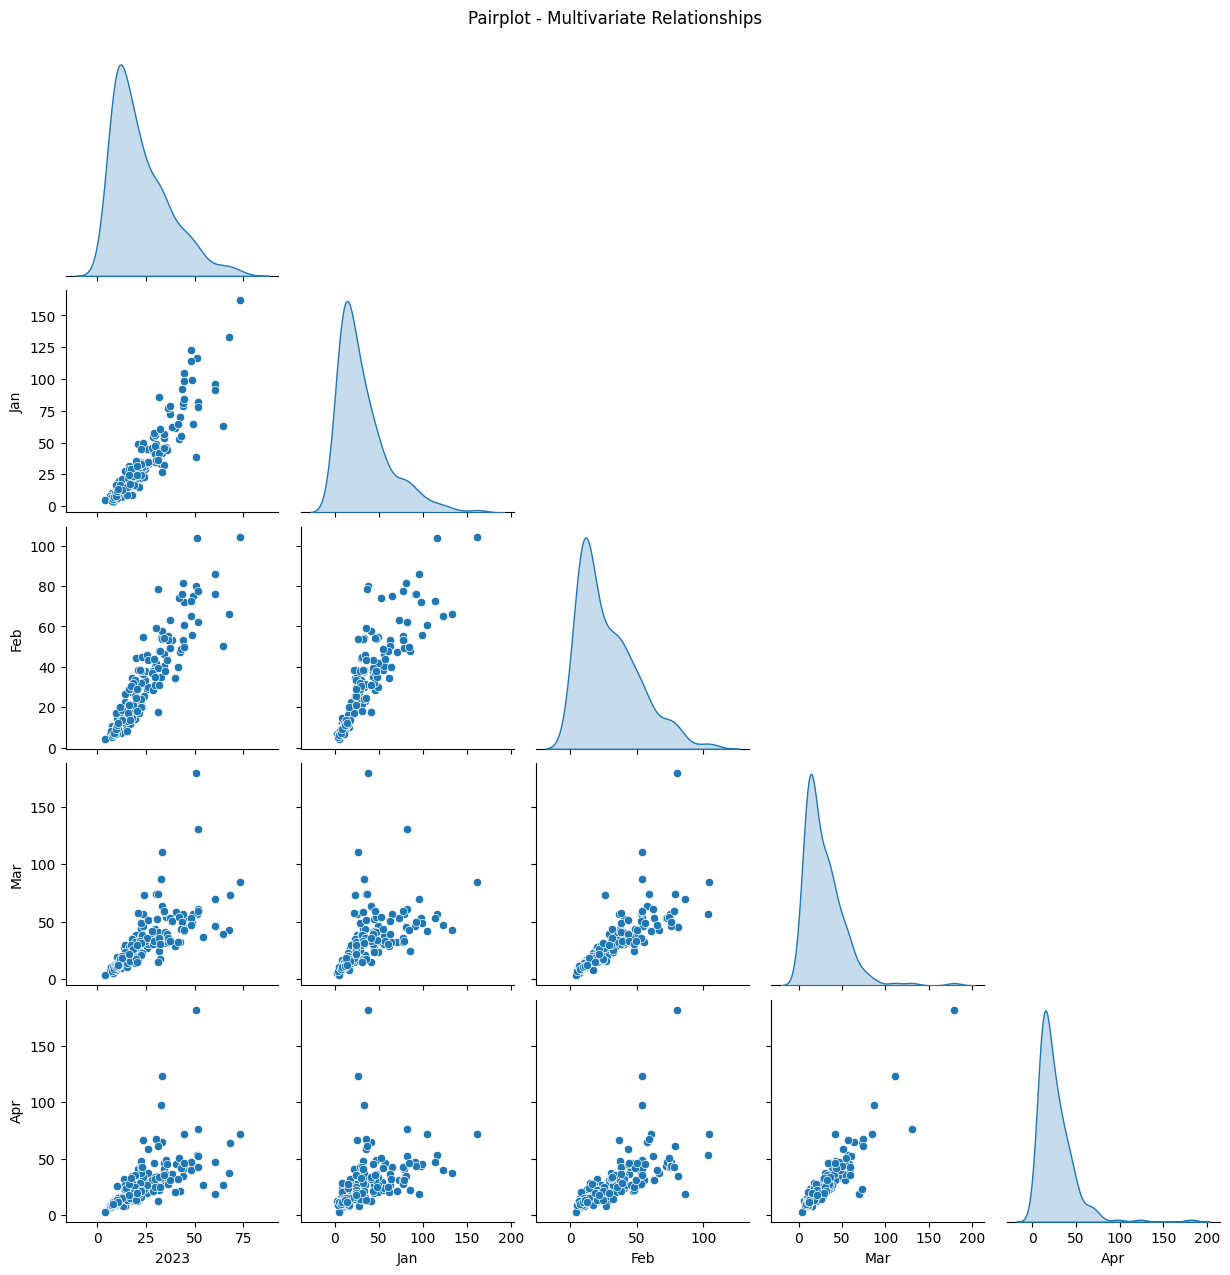

In [ ]:
# MULTIVARIATE ANALYSIS
# ==========================================

# Pairplot (sample to save time)
sns.pairplot(df.sample(200), vars=['2023','Jan','Feb','Mar','Apr'], diag_kind='kde', corner=True)
plt.suptitle("Pairplot - Multivariate Relationships", y=1.02)
plt.show()

In [ ]:
# PCA for dimensionality reduction
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

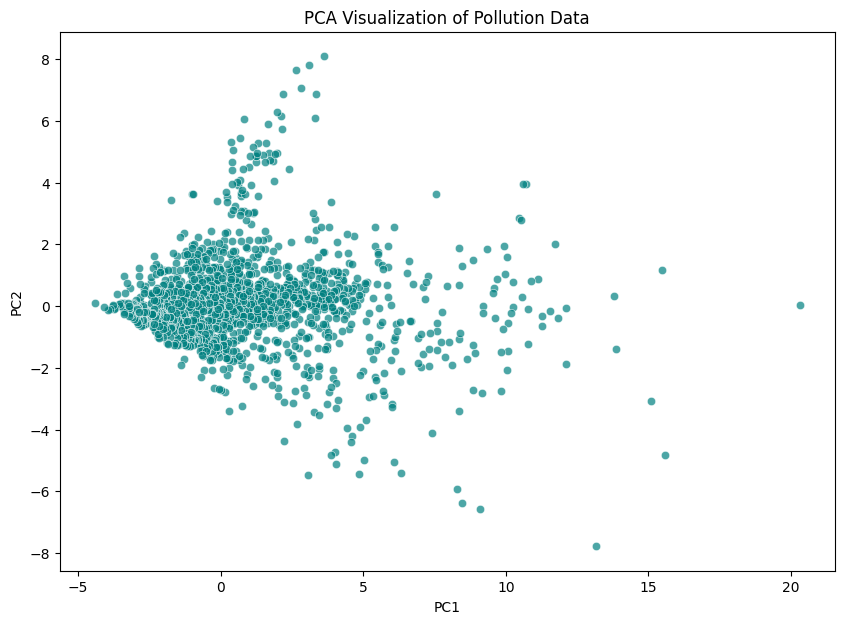

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_mean[numeric_cols])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])

plt.figure(figsize=(10,7))
sns.scatterplot(x='PC1', y='PC2', data=df_pca, alpha=0.7, color='teal')
plt.title("PCA Visualization of Pollution Data")
plt.show()

In [ ]:
# Ensure dataset / numeric columns are available
if 'df_mean' in globals():
    df_used = df_mean.copy()
elif 'df' in globals():
    # create a simple mean-imputed copy if user only has df
    numeric_cols = list(df.columns[3:])
    tmp = df.copy()
    for c in numeric_cols:
        tmp[c] = pd.to_numeric(tmp[c], errors='coerce')
    from sklearn.impute import SimpleImputer
    mean_imp = SimpleImputer(strategy='mean')
    tmp[numeric_cols] = mean_imp.fit_transform(tmp[numeric_cols])
    df_used = tmp
    print("df_mean not found — created mean-imputed dataframe as `df_used`.")
else:
    raise RuntimeError("Neither `df_mean` nor `df` exist in the environment. Load your dataframe first.")


In [ ]:
# Identify numeric feature columns (2023 + months)
numeric_cols = list(df_used.columns[3:])  # adjust if your structure differs
print(f"Numeric features: {numeric_cols}")

Numeric features: ['2023', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


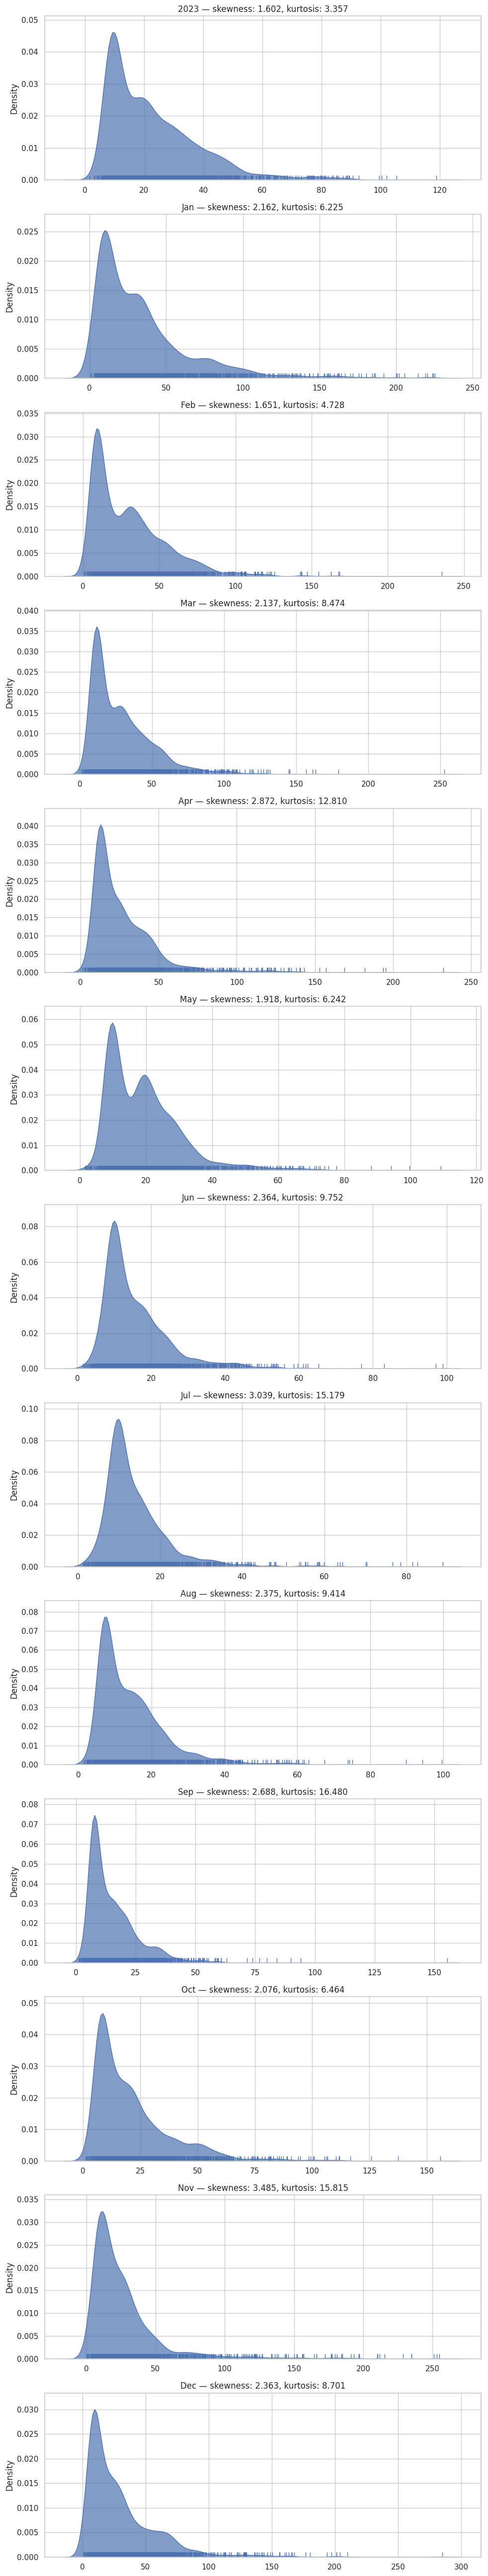

Skewness & Kurtosis summary (abs-skewness desc):


,feature,skewness,kurtosis
11,Nov,3.484880,15.815300
7,Jul,3.039085,15.178747
4,Apr,2.872452,12.809828
9,Sep,2.687973,16.479656
8,Aug,2.375105,9.413953
6,Jun,2.363641,9.752006
12,Dec,2.362958,8.700835
1,Jan,2.162180,6.224619
3,Mar,2.137058,8.474364
10,Oct,2.075524,6.464165


In [ ]:
# 1) KDE plots + skewness & kurtosis for all numeric features
stats_summary = []
plt.figure(figsize=(10, 4 * len(numeric_cols)))
for i, col in enumerate(numeric_cols, start=1):
    vals = pd.to_numeric(df_used[col], errors='coerce').dropna()
    skew = scs.skew(vals)
    kurt = scs.kurtosis(vals, fisher=True)  # fisher=True: normal => 0
    stats_summary.append({'feature': col, 'skewness': float(skew), 'kurtosis': float(kurt)})
    ax = plt.subplot(len(numeric_cols), 1, i)
    sns.kdeplot(vals, fill=True, bw_adjust=0.8, alpha=0.7)
    sns.rugplot(vals, height=0.03)
    ax.set_title(f"{col} — skewness: {skew:.3f}, kurtosis: {kurt:.3f}")
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

stats_df = pd.DataFrame(stats_summary).sort_values(by='skewness', key=lambda s: s.abs(), ascending=False)
print("Skewness & Kurtosis summary (abs-skewness desc):")
display(stats_df)

In [ ]:
# 2) Create/confirm class labels for comparison (Low/Medium/High) if not present
if 'pollution_class' not in df_used.columns:
    # create a 3-bin label from '2023' (quantiles). If you have a different label, replace this.
    df_used['pollution_class'] = pd.qcut(df_used['2023'], q=3, labels=['Low', 'Medium', 'High'])
    print("Created 'pollution_class' by qcut(3) on '2023'.")
else:
    print("'pollution_class' already present — using existing labels.")

print("Class distribution:")
display(df_used['pollution_class'].value_counts())

Created 'pollution_class' by qcut(3) on '2023'.
Class distribution:


,count
pollution_class,
Low,724
High,721
Medium,719


In [ ]:
# Encode labels
le = LabelEncoder()
y = le.fit_transform(df_used['pollution_class'])

# 3) Standardize numeric features for DR & clustering
X = df_used[numeric_cols].astype(float).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# 4) Dimensionality Reduction: PCA, t-SNE, UMAP
# PCA (2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA explained variance ratio (2 comps): {pca.explained_variance_ratio_.round(4)}")

# t-SNE (2D) — relatively slow; tune perplexity if needed
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X_scaled)

# UMAP (2D)
umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = umap_reducer.fit_transform(X_scaled)

PCA explained variance ratio (2 comps): [0.6953 0.1289]


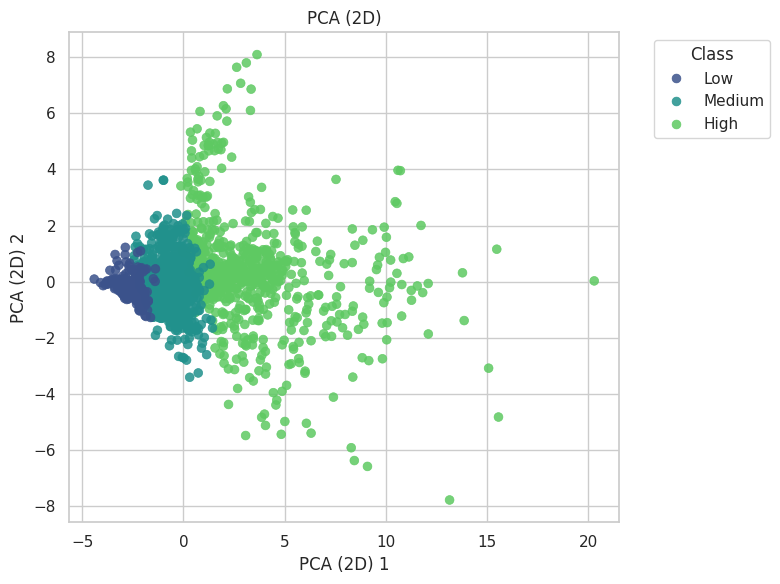

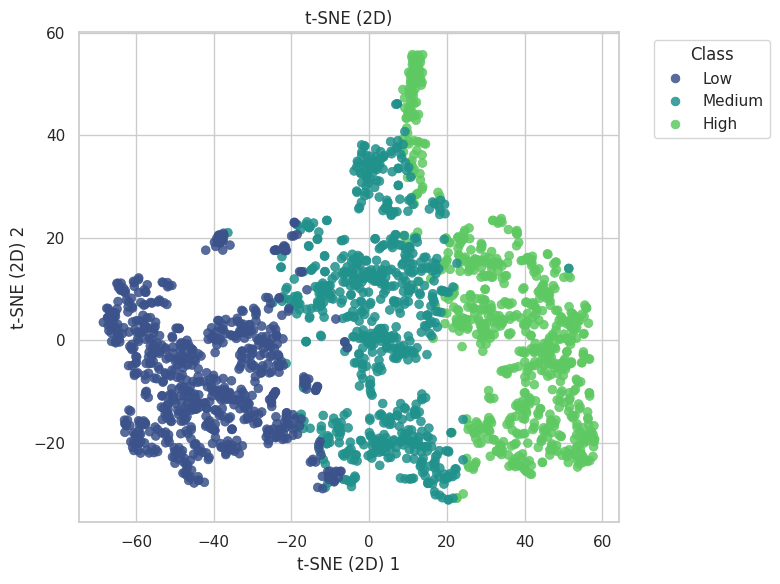

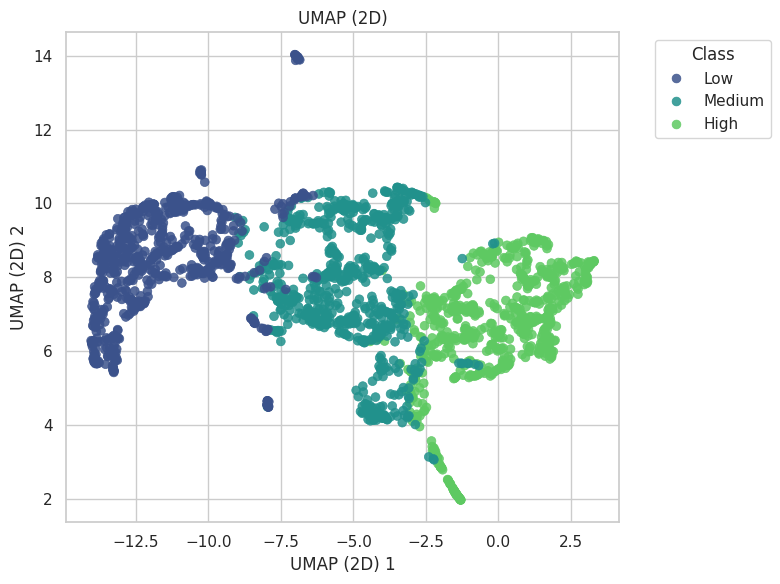

In [ ]:
# Function to plot embeddings colored by true class
def plot_embedding(emb, title, labels, palette='viridis'):
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=emb[:,0], y=emb[:,1], hue=labels, palette=palette, s=40, alpha=0.85, edgecolor=None)
    plt.title(title)
    plt.xlabel(f"{title} 1")
    plt.ylabel(f"{title} 2")
    plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_embedding(X_pca, 'PCA (2D)', df_used['pollution_class'])
plot_embedding(X_tsne, 't-SNE (2D)', df_used['pollution_class'])
plot_embedding(X_umap, 'UMAP (2D)', df_used['pollution_class'])


--- Clustering on PCA ---
KMeans: clusters=3  ARI=0.436  NMI=0.551  Silhouette=0.520


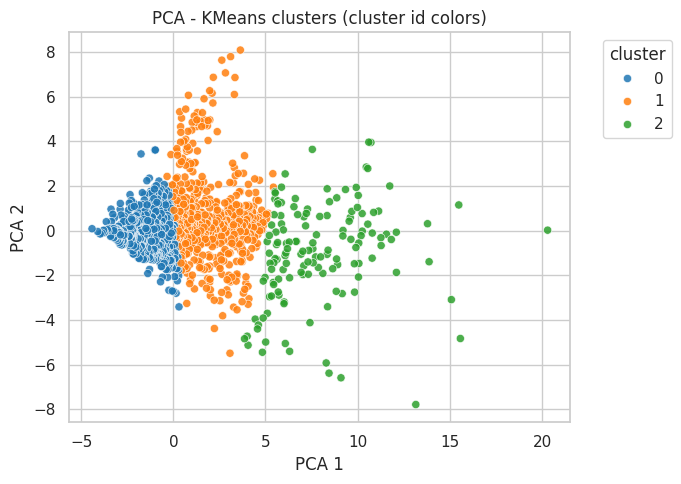

DBSCAN: clusters=3  ARI=0.008  NMI=0.072  Silhouette=0.584


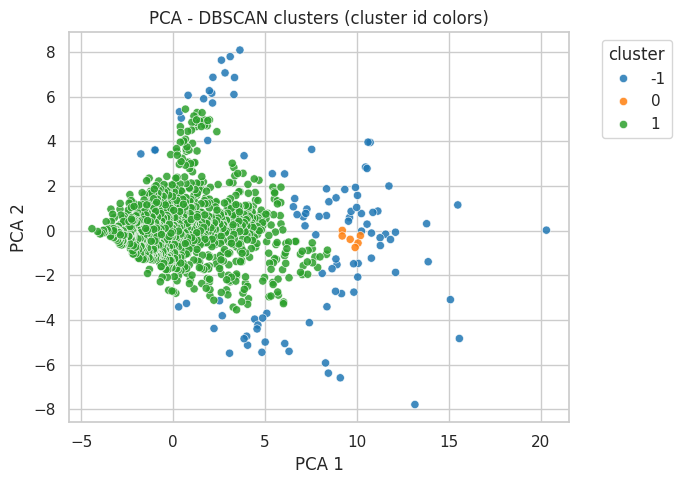

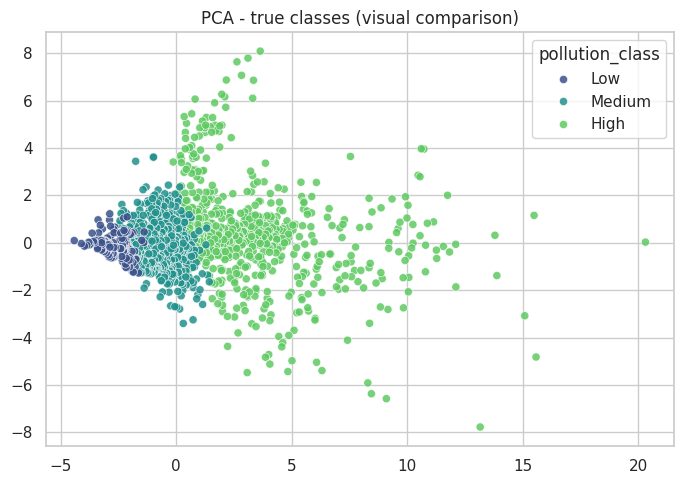

Contingency table (KMeans vs true_class):


true_class,Low,Medium,High
kmeans_cluster,,,
0,724,609,0
1,0,110,581
2,0,0,140



--- Clustering on UMAP ---
KMeans: clusters=3  ARI=0.788  NMI=0.752  Silhouette=0.493


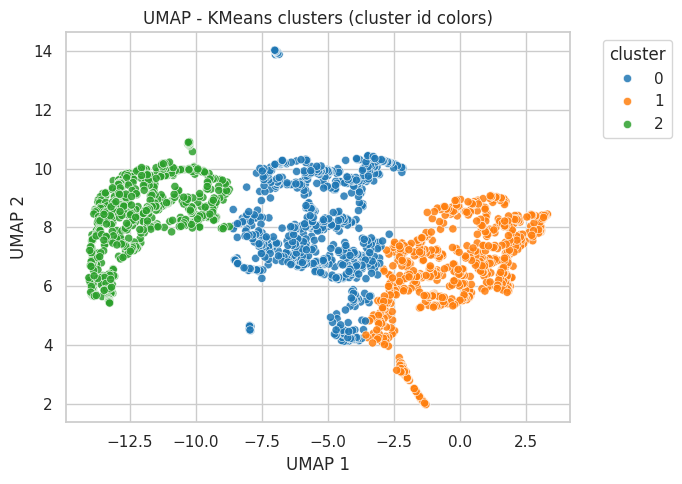

DBSCAN: clusters=3  ARI=0.001  NMI=0.027  Silhouette=-0.067


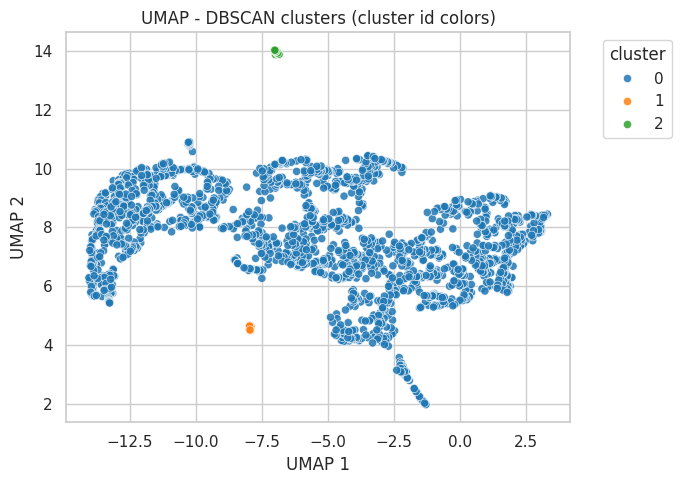

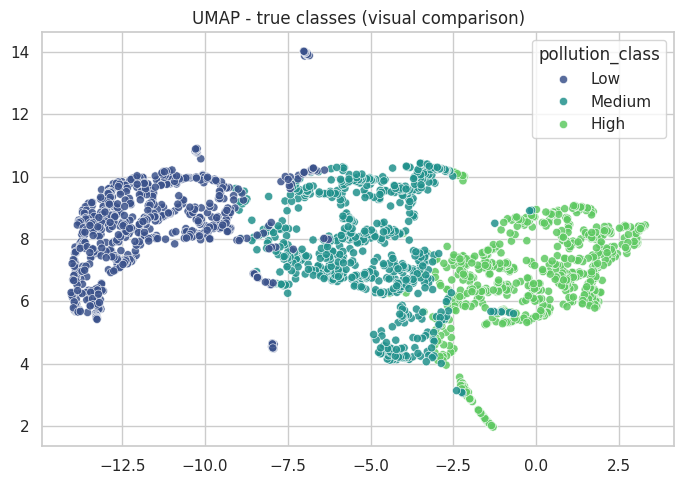

Contingency table (KMeans vs true_class):


true_class,Low,Medium,High
kmeans_cluster,,,
0,88,669,26
1,0,41,695
2,636,9,0


In [ ]:
# 5) Clustering: KMeans and DBSCAN on embeddings (use PCA & UMAP embeddings)
def clustering_and_evaluate(X_emb, emb_name, true_labels):
    print(f"\n--- Clustering on {emb_name} ---")
    # KMeans (k = number of true classes)
    k = len(np.unique(true_labels))
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_labels = kmeans.fit_predict(X_emb)

    # DBSCAN: eps and min_samples might need tuning depending on dataset scale
    db = DBSCAN(eps=0.6, min_samples=6)  # reasonable defaults; adjust if too many -1 labels
    db_labels = db.fit_predict(X_emb)

    # Metrics against true labels (encoded)
    for name, labels in [('KMeans', km_labels), ('DBSCAN', db_labels)]:
        unique_labels = set(labels)
        if len(unique_labels) <= 1 or (unique_labels == {-1}):
            ari = nmi = sil = np.nan
        else:
            ari = adjusted_rand_score(y, labels)
            nmi = normalized_mutual_info_score(y, labels)
            # silhouette requires at least 2 clusters and no single cluster
            try:
                sil = silhouette_score(X_emb, labels)
            except:
                sil = np.nan
        print(f"{name}: clusters={len(unique_labels)}  ARI={ari:.3f}  NMI={nmi:.3f}  Silhouette={sil:.3f}")

        # scatter by cluster id
        plt.figure(figsize=(7,5))
        sns.scatterplot(x=X_emb[:,0], y=X_emb[:,1], hue=labels, palette='tab10', s=35, alpha=0.85, legend='full')
        plt.title(f"{emb_name} - {name} clusters (cluster id colors)")
        plt.xlabel(f"{emb_name} 1"); plt.ylabel(f"{emb_name} 2")
        plt.legend(title='cluster', bbox_to_anchor=(1.05,1), loc='upper left')
        plt.tight_layout()
        plt.show()

    # show true classes too for visual comparison
    plt.figure(figsize=(7,5))
    sns.scatterplot(x=X_emb[:,0], y=X_emb[:,1], hue=df_used['pollution_class'], palette='viridis', s=35, alpha=0.85)
    plt.title(f"{emb_name} - true classes (visual comparison)")
    plt.tight_layout()
    plt.show()

    # contingency table for KMeans vs true classes
    kmeans_labels = km_labels
    ct = pd.crosstab(kmeans_labels, df_used['pollution_class'], rownames=['kmeans_cluster'], colnames=['true_class'])
    print("Contingency table (KMeans vs true_class):")
    display(ct)

# Run on PCA and UMAP embeddings
clustering_and_evaluate(X_pca, 'PCA', df_used['pollution_class'])
clustering_and_evaluate(X_umap, 'UMAP', df_used['pollution_class'])

In [ ]:
# 6) Recursive Feature Elimination (RFE) with RandomForest to get top 5-10 features
X_feat = pd.DataFrame(X_scaled, columns=numeric_cols)  # standardized features for RFE
y_labels = y  # encoded true class labels

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

# We'll try to select top_k in [5, 7, 10] depending on availability
max_k = min(10, X_feat.shape[1])
top_ks = [5, 7, 10]
top_ks = [k for k in top_ks if k <= max_k]

rfe_results = {}
for k in top_ks:
    selector = RFE(estimator=rf, n_features_to_select=k, step=1)
    selector = selector.fit(X_feat, y_labels)
    selected = X_feat.columns[selector.support_].tolist()
    ranking = pd.DataFrame({'feature': X_feat.columns, 'ranking': selector.ranking_}).sort_values('ranking')
    print(f"\nRFE selected top {k} features:")
    print(selected)
    display(ranking.head(k))
    rfe_results[k] = selected



RFE selected top 5 features:
['2023', 'Feb', 'May', 'Nov', 'Dec']


,feature,ranking
0,2023,1
2,Feb,1
5,May,1
11,Nov,1
12,Dec,1



RFE selected top 7 features:
['2023', 'Jan', 'Feb', 'May', 'Oct', 'Nov', 'Dec']


,feature,ranking
0,2023,1
1,Jan,1
2,Feb,1
5,May,1
10,Oct,1
12,Dec,1
11,Nov,1



RFE selected top 10 features:
['2023', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Aug', 'Oct', 'Nov', 'Dec']


,feature,ranking
0,2023,1
1,Jan,1
2,Feb,1
3,Mar,1
4,Apr,1
5,May,1
10,Oct,1
8,Aug,1
11,Nov,1
12,Dec,1



RandomForest feature importances (top 10):


,0
2023,0.336032
Feb,0.121801
May,0.120035
Dec,0.074453
Jan,0.073978
Oct,0.072107
Nov,0.061444
Mar,0.055859
Apr,0.033470
Aug,0.018099


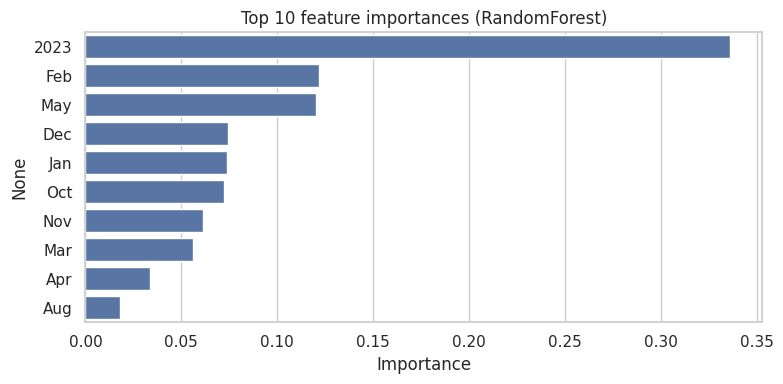

In [ ]:
# Also provide RandomForest feature importances as an additional guide
rf.fit(X_feat, y_labels)
importances = pd.Series(rf.feature_importances_, index=X_feat.columns).sort_values(ascending=False)
print("\nRandomForest feature importances (top 10):")
display(importances.head(10))

# Optional: plot top importances
plt.figure(figsize=(8,4))
sns.barplot(x=importances.head(10).values, y=importances.head(10).index)
plt.title("Top 10 feature importances (RandomForest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [ ]:
# ---- Prepare dataset and features
if 'df_used' in globals():
    df_work = df_used.copy()
elif 'df_mean' in globals():
    df_work = df_mean.copy()
elif 'df' in globals():
    # create df_mean quickly if necessary
    tmp = df.copy()
    numeric_cols = list(df.columns[3:])
    for c in numeric_cols:
        tmp[c] = pd.to_numeric(tmp[c], errors='coerce')
    imputer = SimpleImputer(strategy='mean')
    tmp[numeric_cols] = imputer.fit_transform(tmp[numeric_cols])
    df_work = tmp
else:
    raise RuntimeError("No dataframe found in environment. Make sure df_used, df_mean, or df exists.")

In [ ]:
# numeric_cols detection (if not present)
if 'numeric_cols' not in globals():
    numeric_cols = list(df_work.columns[3:])

In [ ]:
# create/ensure class labels
if 'pollution_class' not in df_work.columns:
    df_work['pollution_class'] = pd.qcut(df_work['2023'], q=3, labels=['Low','Medium','High'])


In [ ]:
# encode labels (y)
le = LabelEncoder()
y = le.fit_transform(df_work['pollution_class'])

# feature matrix (use mean-imputed numeric features)
X = df_work[numeric_cols].astype(float).copy()

In [ ]:
# standardized copy for models and VIF calculations
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=numeric_cols)

print(f"Dataset ready: X shape = {X.shape}, y shape = {y.shape}")
print("Class distribution:", pd.Series(y).value_counts().to_dict())

Dataset ready: X shape = (2164, 13), y shape = (2164,)
Class distribution: {1: 724, 0: 721, 2: 719}


In [ ]:
# ---- 1) Correlation analyses: Pearson, Spearman, Kendall ----
print("\n=== Correlation matrices ===")
pearson_corr = X.corr(method='pearson')
spearman_corr = X.corr(method='spearman')
kendall_corr = X.corr(method='kendall')


=== Correlation matrices ===


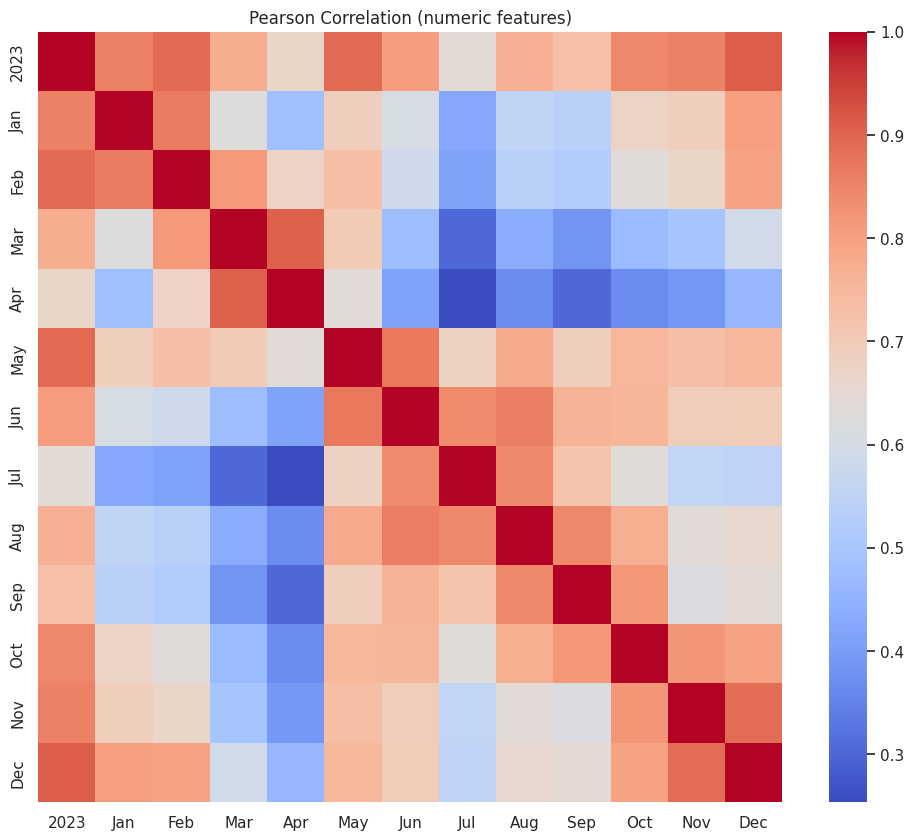

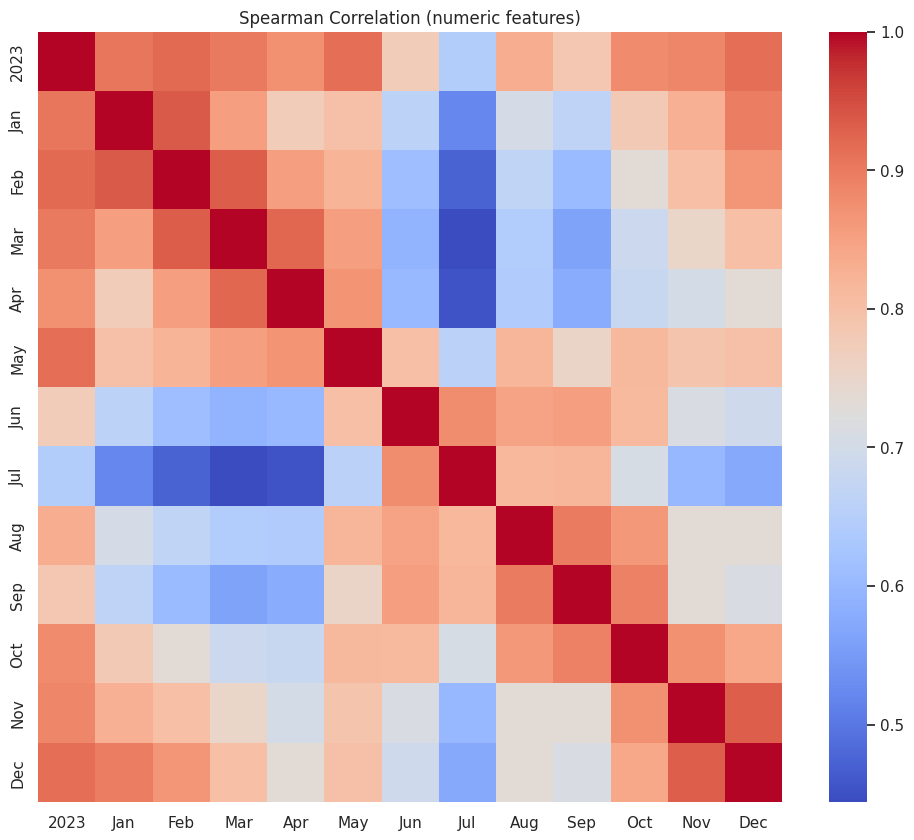

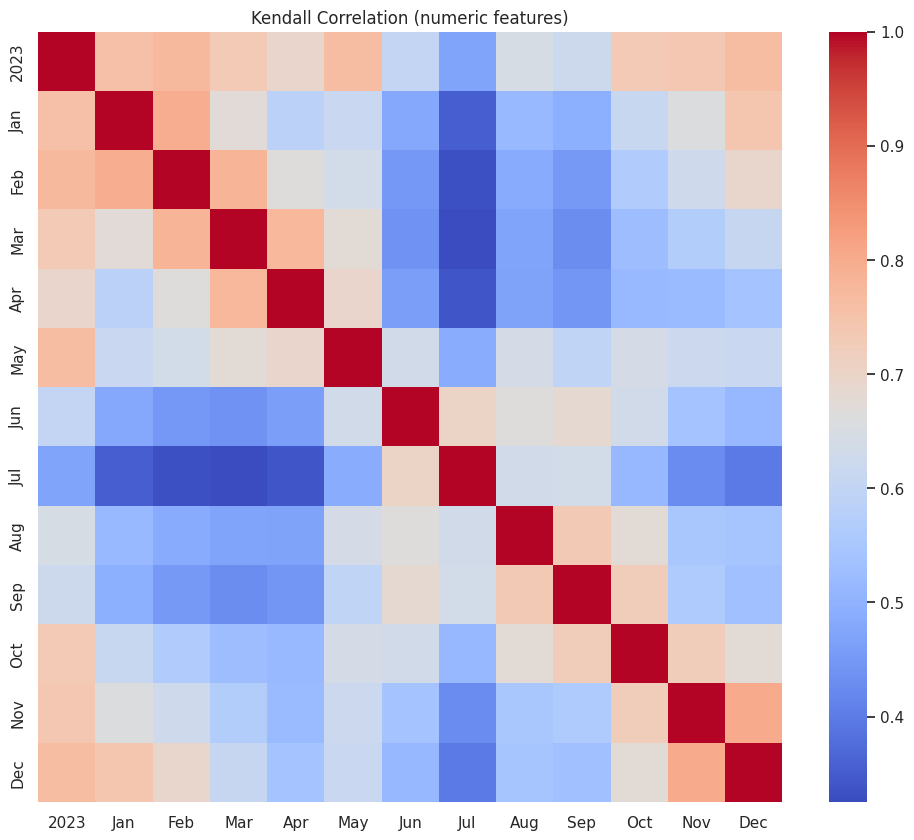

In [ ]:
# show and plot top correlation heatmaps
plt.figure(figsize=(12,10))
sns.heatmap(pearson_corr, annot=False, cmap='coolwarm')
plt.title("Pearson Correlation (numeric features)")
plt.show()

plt.figure(figsize=(12,10))
sns.heatmap(spearman_corr, annot=False, cmap='coolwarm')
plt.title("Spearman Correlation (numeric features)")
plt.show()

plt.figure(figsize=(12,10))
sns.heatmap(kendall_corr, annot=False, cmap='coolwarm')
plt.title("Kendall Correlation (numeric features)")
plt.show()

In [ ]:
# For reporting: top absolute correlations (off-diagonal)
def top_pairs(corrmat, top_n=10):
    corr = corrmat.where(np.triu(np.ones(corrmat.shape), k=1).astype(bool))
    corr_unstacked = corr.abs().unstack().dropna().sort_values(ascending=False)
    return corr_unstacked.head(top_n)

print("\nTop Pearson absolute correlations (feature pairs):")
display(top_pairs(pearson_corr, top_n=10))

print("\nTop Spearman absolute correlations (feature pairs):")
display(top_pairs(spearman_corr, top_n=10))



Top Pearson absolute correlations (feature pairs):


,,0
Dec,2023,0.911448
Apr,Mar,0.904442
May,2023,0.892671
Feb,2023,0.889487
Dec,Nov,0.887726
Jun,May,0.870681
Feb,Jan,0.863128
Aug,Jun,0.862584
Nov,2023,0.856800
Jan,2023,0.855299



Top Spearman absolute correlations (feature pairs):


,,0
Feb,Jan,0.934872
Mar,Feb,0.934040
Dec,Nov,0.931982
Apr,Mar,0.922345
Feb,2023,0.919960
May,2023,0.914885
Dec,2023,0.914706
Jan,2023,0.905495
Mar,2023,0.901792
Sep,Aug,0.900081



=== Mutual Information (feature -> pollution_class) ===


,0
2023,1.099070
Feb,0.699392
May,0.680261
Dec,0.676604
Oct,0.667152
Nov,0.649502
Jan,0.647608
Mar,0.632654
Apr,0.557962
Aug,0.491510


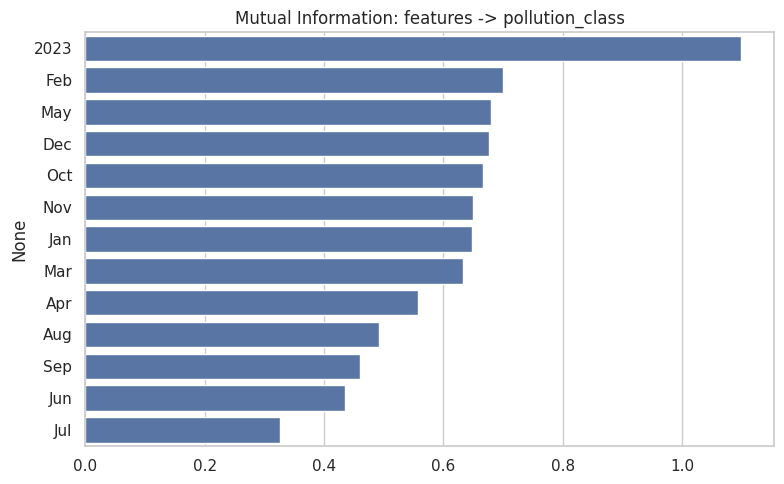

In [ ]:
# ---- 2) Mutual Information (feature -> class) ----
print("\n=== Mutual Information (feature -> pollution_class) ===")
mi = mutual_info_classif(X, y, random_state=42, discrete_features=False)
mi_series = pd.Series(mi, index=numeric_cols).sort_values(ascending=False)
display(mi_series.head(15))

plt.figure(figsize=(8,5))
sns.barplot(x=mi_series.values, y=mi_series.index)
plt.title("Mutual Information: features -> pollution_class")
plt.tight_layout()
plt.show()

In [ ]:
# ---- 3) VIF (Variance Inflation Factor) - multicollinearity ----
print("\n=== VIF calculation ===")
# VIF requires no constant terms and no perfect multicollinearity.
# Use scaled features for stability
X_vif = X_scaled.copy()
X_vif['const'] = 1  # add constant column so we can drop it after
vif_data = []
for i, col in enumerate(numeric_cols):
    vif = variance_inflation_factor(X_vif[numeric_cols].values, i)
    vif_data.append({'feature': col, 'VIF': float(vif)})
vif_df = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)
display(vif_df.head(20))


=== VIF calculation ===


,feature,VIF
0,2023,139.132977
12,Dec,11.576089
3,Mar,11.447483
2,Feb,11.277695
11,Nov,10.049037
6,Jun,9.224178
5,May,9.123812
4,Apr,8.098132
1,Jan,7.922231
8,Aug,7.711111


In [ ]:
# ---- 4) Advanced outlier detection: Isolation Forest & LOF ----
print("\n=== Advanced Outlier Detection ===")
# Use scaled features (no NaNs)
X_for_outliers = X_scaled.values


=== Advanced Outlier Detection ===


In [ ]:
# Isolation Forest
iso = IsolationForest(contamination=0.03, random_state=42)  # adjust contamination as needed
iso_labels = iso.fit_predict(X_for_outliers)  # -1 outlier, 1 inlier
df_work['iso_anomaly'] = (iso_labels == -1).astype(int)
iso_count = df_work['iso_anomaly'].sum()
print(f"IsolationForest flagged {iso_count} anomalies (contamination=0.03)")

IsolationForest flagged 65 anomalies (contamination=0.03)


In [ ]:
# LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)
lof_labels = lof.fit_predict(X_for_outliers)  # -1 outlier, 1 inlier
df_work['lof_anomaly'] = (lof_labels == -1).astype(int)
lof_count = df_work['lof_anomaly'].sum()
print(f"LOF flagged {lof_count} anomalies (contamination=0.03)")


LOF flagged 65 anomalies (contamination=0.03)


In [ ]:
# Intersection / union of anomalies
df_work['anomaly_union'] = ((df_work['iso_anomaly']==1) | (df_work['lof_anomaly']==1)).astype(int)
df_work['anomaly_intersection'] = ((df_work['iso_anomaly']==1) & (df_work['lof_anomaly']==1)).astype(int)
print("Union anomalies:", df_work['anomaly_union'].sum(), "Intersection anomalies:", df_work['anomaly_intersection'].sum())


Union anomalies: 126 Intersection anomalies: 4


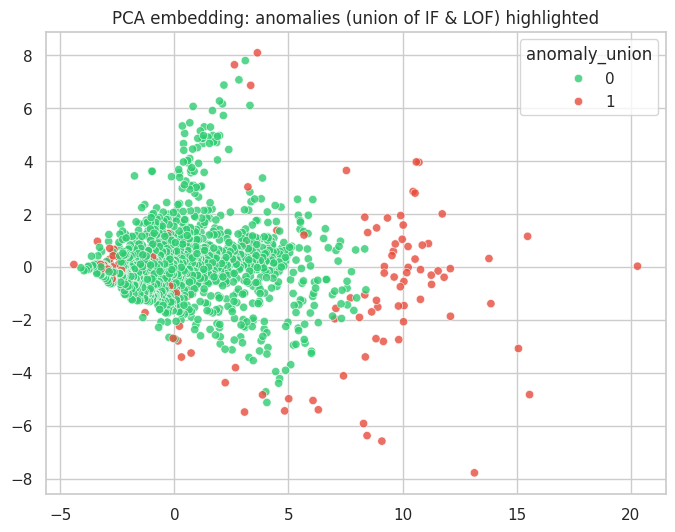

In [ ]:
# Visualize anomalies in PCA embedding for quick inspection
from sklearn.decomposition import PCA
pca2 = PCA(n_components=2, random_state=42)
emb = pca2.fit_transform(X_for_outliers)
plt.figure(figsize=(8,6))
sns.scatterplot(x=emb[:,0], y=emb[:,1], hue=df_work['anomaly_union'], palette=['#2ecc71','#e74c3c'], alpha=0.8)
plt.title("PCA embedding: anomalies (union of IF & LOF) highlighted")
plt.legend(title='anomaly_union', loc='best')
plt.show()


In [ ]:
# ---- 5) Predictive modelling ----
# Prepare training/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)
print("\nTrain/test split:", X_train.shape, X_test.shape)


Train/test split: (1731, 13) (433, 13)


In [ ]:
# Define models
models = {
    'LogisticRegression': LogisticRegression(max_iter=500, random_state=42),
    'SVM_rbf': SVC(kernel='rbf', probability=True, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, verbosity=0),
    'CatBoost': CatBoostClassifier(verbose=0, random_state=42)
}


Model: LogisticRegression
Accuracy: 0.9654  Precision(macro): 0.9654  Recall(macro): 0.9653  F1(macro): 0.9654  ROC_AUC: 0.998647127320615
              precision    recall  f1-score   support

        High       0.99      0.98      0.98       144
         Low       0.96      0.97      0.97       145
      Medium       0.95      0.94      0.95       144

    accuracy                           0.97       433
   macro avg       0.97      0.97      0.97       433
weighted avg       0.97      0.97      0.97       433



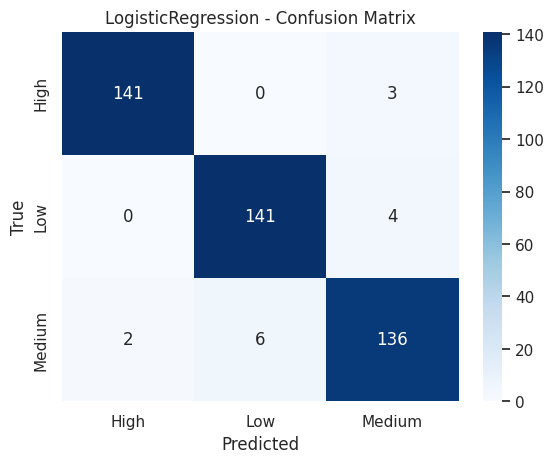


Model: SVM_rbf
Accuracy: 0.9654  Precision(macro): 0.9655  Recall(macro): 0.9653  F1(macro): 0.9653  ROC_AUC: 0.9980225057117731
              precision    recall  f1-score   support

        High       0.99      0.97      0.98       144
         Low       0.96      0.98      0.97       145
      Medium       0.95      0.94      0.95       144

    accuracy                           0.97       433
   macro avg       0.97      0.97      0.97       433
weighted avg       0.97      0.97      0.97       433



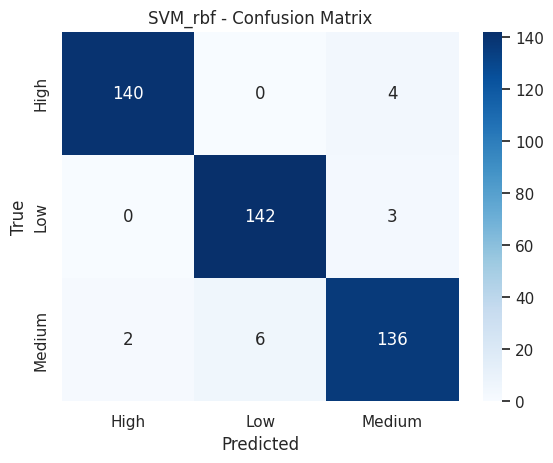


Model: RandomForest
Accuracy: 1.0000  Precision(macro): 1.0000  Recall(macro): 1.0000  F1(macro): 1.0000  ROC_AUC: 1.0
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       144
         Low       1.00      1.00      1.00       145
      Medium       1.00      1.00      1.00       144

    accuracy                           1.00       433
   macro avg       1.00      1.00      1.00       433
weighted avg       1.00      1.00      1.00       433



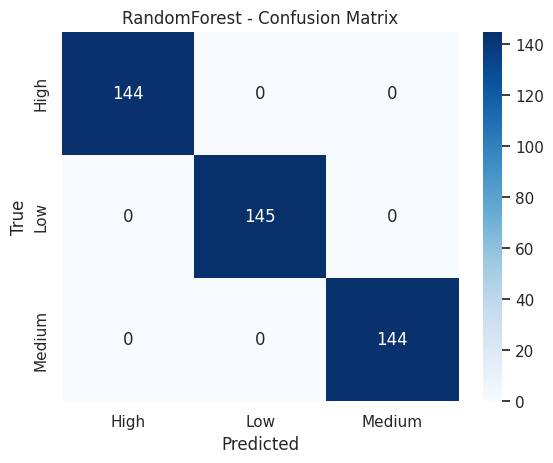


Model: XGBoost
Accuracy: 1.0000  Precision(macro): 1.0000  Recall(macro): 1.0000  F1(macro): 1.0000  ROC_AUC: 1.0
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       144
         Low       1.00      1.00      1.00       145
      Medium       1.00      1.00      1.00       144

    accuracy                           1.00       433
   macro avg       1.00      1.00      1.00       433
weighted avg       1.00      1.00      1.00       433



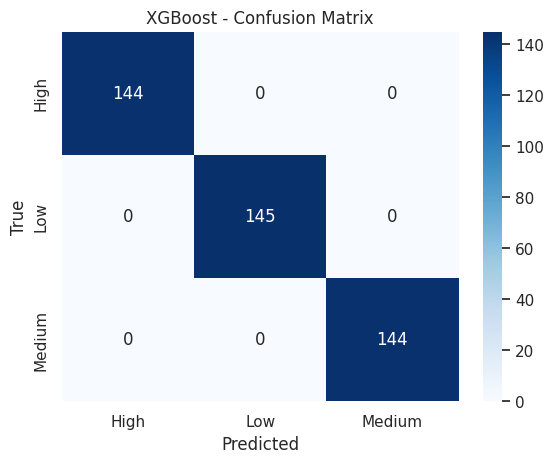


Model: CatBoost
Accuracy: 0.9977  Precision(macro): 0.9977  Recall(macro): 0.9977  F1(macro): 0.9977  ROC_AUC: 1.0
              precision    recall  f1-score   support

        High       0.99      1.00      1.00       144
         Low       1.00      1.00      1.00       145
      Medium       1.00      0.99      1.00       144

    accuracy                           1.00       433
   macro avg       1.00      1.00      1.00       433
weighted avg       1.00      1.00      1.00       433



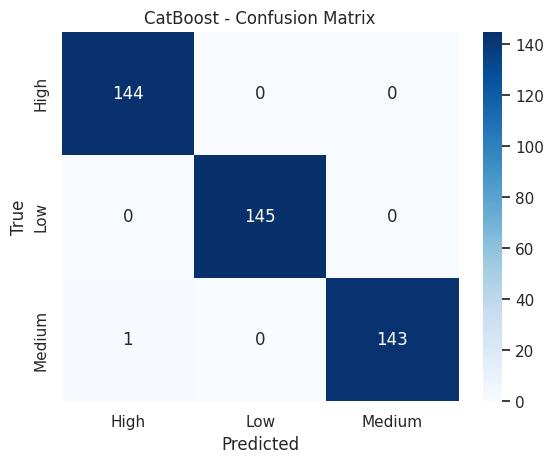

In [ ]:
# Function to train & evaluate a model (single train-test)
def fit_eval(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = None
    try:
        y_proba = model.predict_proba(X_te)
    except:
        pass

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_te, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_te, y_pred, average='macro', zero_division=0)
    # multiclass ROC AUC (one-vs-rest) if probabilities available
    try:
        if y_proba is not None and y_proba.shape[1] > 1:
            roc = roc_auc_score(pd.get_dummies(y_te), y_proba, average='macro', multi_class='ovr')
        else:
            roc = np.nan
    except Exception:
        roc = np.nan

    print(f"\nModel: {name}")
    print(f"Accuracy: {acc:.4f}  Precision(macro): {prec:.4f}  Recall(macro): {rec:.4f}  F1(macro): {f1:.4f}  ROC_AUC: {roc if not np.isnan(roc) else 'N/A'}")
    print(classification_report(y_te, y_pred, zero_division=0, target_names=le.classes_))
    # confusion matrix
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.show()
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': roc}

# Fit & evaluate each model
results = {}
for name, model in models.items():
    try:
        results[name] = fit_eval(name, model, X_train, X_test, y_train, y_test)
    except Exception as e:
        print(f"Error training {name}: {e}")

In [ ]:
# ---- 6) Cross-validated performance (StratifiedKFold) ----
print("\n=== Cross-validated scores (5-fold StratifiedKFold) for classical models ===")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv_results = {}
for name, model in models.items():
    try:
        scores = cross_validate(model, X_scaled, y, cv=skf, scoring=cv_metrics, n_jobs=-1)
        avg_scores = {metric: float(np.mean(scores[f'test_{metric}'])) for metric in cv_metrics}
        cv_results[name] = avg_scores
        print(f"\n{name} CV:")
        for metric, val in avg_scores.items():
            print(f"  {metric}: {val:.4f}")
    except Exception as e:
        print(f"CV error for {name}: {e}")


=== Cross-validated scores (5-fold StratifiedKFold) for classical models ===

LogisticRegression CV:
  accuracy: 0.9709
  precision_macro: 0.9713
  recall_macro: 0.9708
  f1_macro: 0.9708

SVM_rbf CV:
  accuracy: 0.9714
  precision_macro: 0.9718
  recall_macro: 0.9713
  f1_macro: 0.9712

RandomForest CV:
  accuracy: 0.9982
  precision_macro: 0.9982
  recall_macro: 0.9981
  f1_macro: 0.9981

XGBoost CV:
  accuracy: 0.9982
  precision_macro: 0.9982
  recall_macro: 0.9981
  f1_macro: 0.9981

CatBoost CV:
  accuracy: 0.9991
  precision_macro: 0.9991
  recall_macro: 0.9991
  f1_macro: 0.9991



=== Ensembles: Voting and Stacking ===

Model: VotingClassifier (soft)
Accuracy: 0.9861  Precision(macro): 0.9862  Recall(macro): 0.9862  F1(macro): 0.9862  ROC_AUC: 0.9997278898036565
              precision    recall  f1-score   support

        High       0.99      0.99      0.99       144
         Low       0.99      0.98      0.99       145
      Medium       0.97      0.99      0.98       144

    accuracy                           0.99       433
   macro avg       0.99      0.99      0.99       433
weighted avg       0.99      0.99      0.99       433



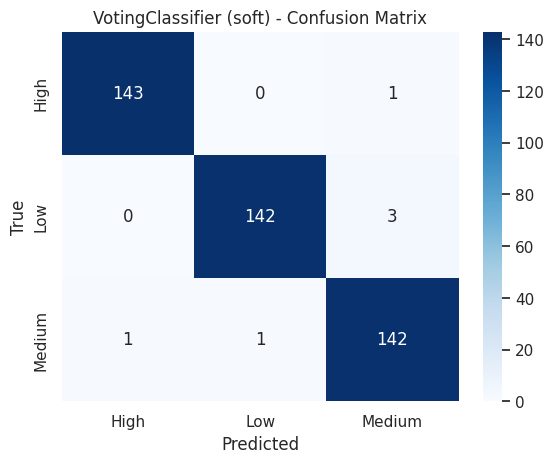


Model: StackingClassifier
Accuracy: 0.9977  Precision(macro): 0.9977  Recall(macro): 0.9977  F1(macro): 0.9977  ROC_AUC: 1.0
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       144
         Low       1.00      0.99      1.00       145
      Medium       0.99      1.00      1.00       144

    accuracy                           1.00       433
   macro avg       1.00      1.00      1.00       433
weighted avg       1.00      1.00      1.00       433



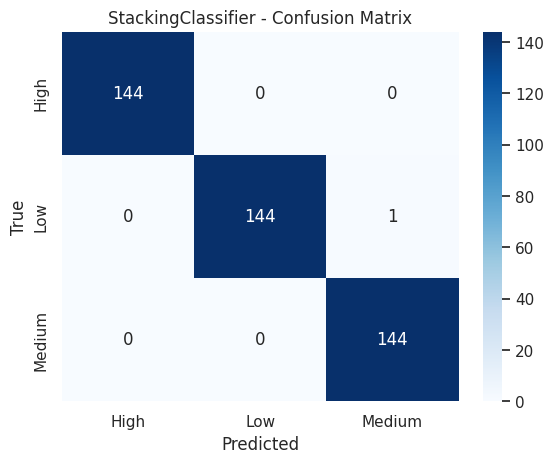


Voting CV results:
  accuracy: 0.9861
  precision_macro: 0.9863
  recall_macro: 0.9861
  f1_macro: 0.9861

Stacking CV results:
  accuracy: 0.9787
  precision_macro: 0.9790
  recall_macro: 0.9787
  f1_macro: 0.9787


In [ ]:
# ---- 7) Ensembles: Voting & Stacking (classical models) ----
print("\n=== Ensembles: Voting and Stacking ===")
# Use three classical models for ensembles: LogisticRegression, SVM (prob), RandomForest
clf1 = LogisticRegression(max_iter=500, random_state=42)
clf2 = SVC(kernel='rbf', probability=True, random_state=42)
clf3 = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

# Voting (soft) - requires probability estimates
voting = VotingClassifier(estimators=[('lr', clf1), ('svm', clf2), ('rf', clf3)], voting='soft', n_jobs=-1)
voting.fit(X_train, y_train)
v_results = fit_eval('VotingClassifier (soft)', voting, X_train, X_test, y_train, y_test)

# Stacking - use same base learners and a LogisticRegression as final estimator
stack = StackingClassifier(estimators=[('lr', clf1), ('svm', clf2), ('rf', clf3)],
                           final_estimator=LogisticRegression(max_iter=500),
                           passthrough=False, n_jobs=-1)
stack.fit(X_train, y_train)
s_results = fit_eval('StackingClassifier', stack, X_train, X_test, y_train, y_test)

# Optionally, cross-validate ensembles
for name, ensemble in [('Voting', voting), ('Stacking', stack)]:
    try:
        scores = cross_validate(ensemble, X_scaled, y, cv=skf, scoring=cv_metrics, n_jobs=-1)
        avg_scores = {metric: float(np.mean(scores[f'test_{metric}'])) for metric in cv_metrics}
        print(f"\n{name} CV results:")
        for metric, val in avg_scores.items():
            print(f"  {metric}: {val:.4f}")
    except Exception as e:
        print(f"CV error for ensemble {name}: {e}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import pandas as pd
file_path = '/content/drive/MyDrive/AirQuality Dataset.csv'
df = pd.read_csv(file_path)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/AirQuality Dataset.csv'

November 12th

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.feature_selection import RFE

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("AirQuality Dataset.csv")
df.head()

Saving AirQuality Dataset.csv to AirQuality Dataset.csv


,Rank,City,Country,2023,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,1,Begusarai,India,118.9,31.2,235.3,156.8,113,109.3,99,63.8,61.8,71.5,61.8,210.5,285
1,2,Guwahati,India,105.4,220.2,168.1,129.2,112.2,69.5,51.3,46.6,60.2,76.7,76.4,126.9,128
2,3,Delhi,India,102.1,171.8,114.3,77.4,71,67.4,42.9,35.3,34.8,39.7,106.3,255.1,210
3,4,Mullanpur,India,100.4,106.3,123.7,78.1,56.6,53.4,53.9,63.2,59.7,59.6,110.4,253,201.4
4,5,Lahore,Pakistan,99.5,143.2,117.3,73.8,52.9,52.4,46.4,39.8,42.2,53.8,125.9,251,197.5


In [ ]:
# Basic info
print(df.info())
print(df.describe())
print(df.isnull().sum())

# Drop rows with missing values (simplest cleaning)
df.dropna(inplace=True)

# Encode categorical columns if any
cat_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Display cleaned dataset
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2164 entries, 0 to 2163
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Rank     2164 non-null   int64  
 1   City     2164 non-null   object 
 2   Country  2164 non-null   object 
 3   2023     2164 non-null   float64
 4   Jan      2164 non-null   object 
 5   Feb      2164 non-null   object 
 6   Mar      2164 non-null   object 
 7   Apr      2164 non-null   object 
 8   May      2164 non-null   object 
 9   Jun      2164 non-null   object 
 10  Jul      2164 non-null   object 
 11  Aug      2164 non-null   object 
 12  Sep      2164 non-null   object 
 13  Oct      2164 non-null   object 
 14  Nov      2164 non-null   object 
 15  Dec      2164 non-null   object 
dtypes: float64(1), int64(1), object(14)
memory usage: 270.6+ KB
None
              Rank         2023
count  2164.000000  2164.000000
mean   1082.500000    23.196811
std     624.837312    16.075976
min       1

,Rank,City,Country,2023,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,1,175,9,118.9,312,174,91,30,14,380,300,345,379,473,189,248
1,2,504,9,105.4,222,106,56,29,403,321,262,342,381,510,65,57
2,3,347,9,102.1,161,39,594,527,401,288,229,238,284,18,233,181
3,4,1181,9,100.4,32,58,597,470,361,328,299,331,356,30,232,169
4,5,1012,24,99.5,112,42,584,453,359,302,242,287,349,44,231,155


In [ ]:
# Load dataset
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.feature_selection import RFE

# Drop unnecessary columns
df = df.drop(columns=['Rank', 'City', 'Country'])

# Creating label based on 2023 AQI
def categorize_aqi(aqi):
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Moderate'
    elif aqi <= 150:
        return 'Unhealthy'
    else:
        return 'Very Unhealthy'

df['AQI_Category'] = df['2023'].apply(categorize_aqi)

# Features: monthly AQI values
X = df.drop(columns=['2023', 'AQI_Category'])
y = df['AQI_Category']

In [ ]:
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
start_time = time.time()

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)

base_time = time.time() - start_time

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("=== Without RFE ===")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Computation Time: {base_time:.4f} seconds")

=== Without RFE ===
Accuracy: 0.9508
Precision: 0.9406
Recall: 0.9508
F1-score: 0.9378
Computation Time: 0.0453 seconds


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ===== RFE Feature Selection =====
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_encoded = y

# Split again (to ensure consistent shape)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

# Baseline model (no RFE)
log_reg = LogisticRegression(max_iter=500)
start = time.time()
log_reg.fit(X_train, y_train)
base_time = time.time() - start

y_pred = log_reg.predict(X_test)

acc_base = accuracy_score(y_test, y_pred)
prec_base = precision_score(y_test, y_pred, average='macro')
rec_base = recall_score(y_test, y_pred, average='macro')
f1_base = f1_score(y_test, y_pred, average='macro')

# ----- With RFE -----
selector = RFE(estimator=LogisticRegression(max_iter=500), n_features_to_select=6)
X_train_rfe = selector.fit_transform(X_train, y_train)
X_test_rfe = selector.transform(X_test)

log_reg_rfe = LogisticRegression(max_iter=500)
start = time.time()
log_reg_rfe.fit(X_train_rfe, y_train)
rfe_time = time.time() - start

y_pred_rfe = log_reg_rfe.predict(X_test_rfe)

acc_rfe = accuracy_score(y_test, y_pred_rfe)
prec_rfe = precision_score(y_test, y_pred_rfe, average='macro')
rec_rfe = recall_score(y_test, y_pred_rfe, average='macro')
f1_rfe = f1_score(y_test, y_pred_rfe, average='macro')

print("\n=== Without RFE ===")
print(f"Accuracy: {acc_base:.4f}")
print(f"Precision: {prec_base:.4f}")
print(f"Recall: {rec_base:.4f}")
print(f"F1-score: {f1_base:.4f}")
print(f"Computation Time: {base_time:.4f} seconds")

print("\n=== With RFE ===")
print(f"Accuracy: {acc_rfe:.4f}")
print(f"Precision: {prec_rfe:.4f}")
print(f"Recall: {rec_rfe:.4f}")
print(f"F1-score: {f1_rfe:.4f}")
print(f"Computation Time: {rfe_time:.4f} seconds")


=== Without RFE ===
Accuracy: 0.9446
Precision: 0.8076
Recall: 0.5745
F1-score: 0.6106
Computation Time: 0.0191 seconds

=== With RFE ===
Accuracy: 0.9423
Precision: 0.9711
Recall: 0.5192
F1-score: 0.5221
Computation Time: 0.0181 seconds



AUC (Without RFE): 0.9435
AUC (With RFE): 0.4690


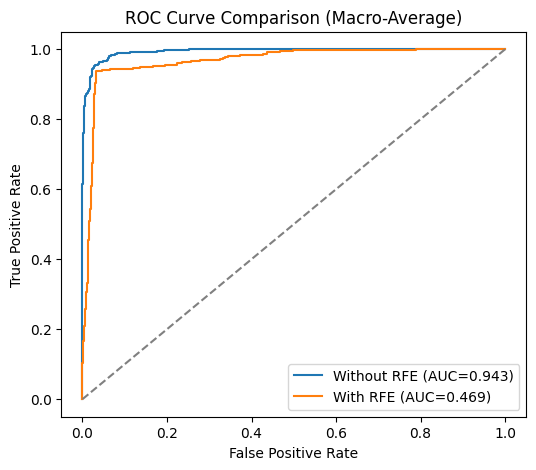

In [ ]:
# AUC and ROC Curve Comparison
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

y_score = log_reg.predict_proba(X_test)
y_score_rfe = log_reg_rfe.predict_proba(X_test_rfe)

auc_base = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')
auc_rfe = roc_auc_score(y_test_bin, y_score_rfe, average='macro', multi_class='ovr')

print(f"\nAUC (Without RFE): {auc_base:.4f}")
print(f"AUC (With RFE): {auc_rfe:.4f}")

# Plot ROC Curve Comparison (Macro-Average)
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
fpr_rfe, tpr_rfe, _ = roc_curve(y_test_bin.ravel(), y_score_rfe.ravel())

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Without RFE (AUC={auc_base:.3f})')
plt.plot(fpr_rfe, tpr_rfe, label=f'With RFE (AUC={auc_rfe:.3f})')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Macro-Average)")
plt.legend()
plt.show()

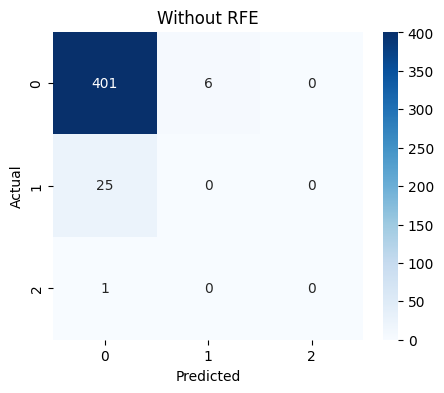

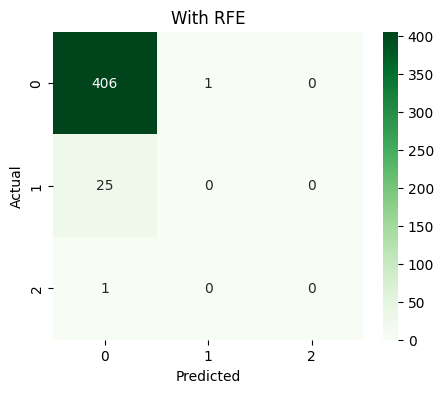

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Without RFE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rfe), annot=True, fmt='d', cmap='Greens')
plt.title("With RFE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
results = pd.DataFrame({
    'Metric': ['Accuracy','Precision','Recall','F1-score','Time (s)'],
    'Without RFE': [acc, prec, rec, f1, base_time],
    'With RFE': [acc_rfe, prec_rfe, rec_rfe, f1_rfe, rfe_time]
})
print(results)

      Metric  Without RFE  With RFE
0   Accuracy     0.950769  0.942263
1  Precision     0.940557  0.971065
2     Recall     0.950769  0.519231
3   F1-score     0.937827  0.522138
4   Time (s)     0.019082  0.018140


Comparison (numeric metrics):


,full,rfe
metric,,
accuracy,0.950769,0.942263
precision_macro,0.940557,0.971065
recall_macro,0.950769,0.519231
f1_macro,0.937827,0.522138
auc_macro_ovr,0.943468,0.468983
train_time_sec,0.019082,0.018140


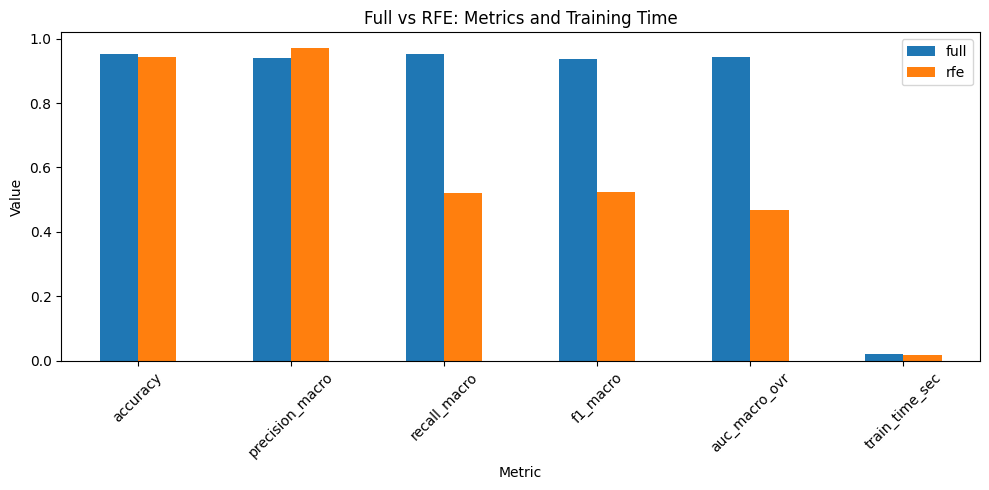

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create dictionary of metrics for Full and RFE models
metrics_full = {
    'accuracy': acc,
    'precision_macro': prec,
    'recall_macro': rec,
    'f1_macro': f1,
    'auc_macro_ovr': auc_base,
    'train_time_sec': base_time,
}

metrics_rfe = {
    'accuracy': acc_rfe,
    'precision_macro': prec_rfe,
    'recall_macro': rec_rfe,
    'f1_macro': f1_rfe,
    'auc_macro_ovr': auc_rfe,
    'train_time_sec': rfe_time,
}

# Keep only numeric metrics for plotting
numeric_keys = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'auc_macro_ovr', 'train_time_sec']
comp_num = pd.DataFrame({
    'metric': numeric_keys,
    'full': [metrics_full.get(k, None) for k in numeric_keys],
    'rfe': [metrics_rfe.get(k, None) for k in numeric_keys]
}).set_index('metric')

print("Comparison (numeric metrics):")
display(comp_num)

# Side-by-side bar plot
ax = comp_num[['full', 'rfe']].plot(kind='bar', figsize=(10,5), rot=45)
plt.title("Full vs RFE: Metrics and Training Time")
plt.ylabel("Value")
plt.xlabel("Metric")
plt.tight_layout()
plt.show()